# Stage 05 — German Credit SHAP Explanations

This notebook explains the frozen weighted XGBoost model using the complete test set and fixed XAI cohort. It does not retrain the model or preprocessing.


## 1. Frozen reconstruction


In [1]:
import json
from importlib.metadata import version
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)

DECISION_THRESHOLD = 0.50
RAW_TARGET = "class"
TARGET = "TARGET"

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "german_credit":
    candidate = NOTEBOOK_DIR / "backend" / "ml" / "german_credit"
    if candidate.exists():
        NOTEBOOK_DIR = candidate
    else:
        raise RuntimeError("Run from backend/ml/german_credit or the project root.")
BACKEND_DIR = NOTEBOOK_DIR.parents[1]
RAW_PATH = BACKEND_DIR / "data" / "german_credit" / "raw" / "german_credit_raw.csv"
ARTIFACTS_DIR = BACKEND_DIR / "artifacts" / "german_credit"
PLOTS_DIR = ARTIFACTS_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "selection": ARTIFACTS_DIR / "selected_features.json",
    "display_mapping": ARTIFACTS_DIR / "feature_display_mapping.json",
    "category_mapping": ARTIFACTS_DIR / "category_value_mapping.json",
    "train_indices": ARTIFACTS_DIR / "train_indices.csv",
    "test_indices": ARTIFACTS_DIR / "test_indices.csv",
    "preprocessor": ARTIFACTS_DIR / "preprocessor.joblib",
    "preprocessing_metadata": ARTIFACTS_DIR / "preprocessing_metadata.json",
    "transformed_mapping": ARTIFACTS_DIR / "transformed_feature_mapping.csv",
    "model": ARTIFACTS_DIR / "xgboost_credit_model.joblib",
    "model_metadata": ARTIFACTS_DIR / "model_metadata.json",
    "xai_cases": ARTIFACTS_DIR / "xai_evaluation_cases.csv",
}
assert all(path.exists() for path in paths.values())
print(f"XGBoost version: {xgb.__version__}")
print(f"SHAP package version: {version('shap')}")


XGBoost version: 3.2.0
SHAP package version: 0.49.1


In [2]:
raw_df = pd.read_csv(RAW_PATH)
selection = json.loads(paths["selection"].read_text(encoding="utf-8"))
display_mapping = json.loads(paths["display_mapping"].read_text(encoding="utf-8"))
category_mapping = json.loads(paths["category_mapping"].read_text(encoding="utf-8"))
preprocessing_metadata = json.loads(paths["preprocessing_metadata"].read_text(encoding="utf-8"))
model_metadata = json.loads(paths["model_metadata"].read_text(encoding="utf-8"))
train_indices = pd.read_csv(paths["train_indices"])["row_index"].astype(int)
test_indices = pd.read_csv(paths["test_indices"])["row_index"].astype(int)
transformed_mapping = pd.read_csv(paths["transformed_mapping"], keep_default_na=False)
xai_cases = pd.read_csv(paths["xai_cases"])
preprocessor = joblib.load(paths["preprocessor"])
model = joblib.load(paths["model"])

selected_features = selection["selected_features"]
numeric_features = selection["numeric_selected_features"]
categorical_features = selection["categorical_selected_features"]
y_all = raw_df[RAW_TARGET].map({1: 0, 2: 1}).rename(TARGET)
X_train_raw = raw_df.loc[train_indices, selected_features].copy()
X_test_raw = raw_df.loc[test_indices, selected_features].copy()
y_test = y_all.loc[test_indices].copy()
X_test_processed = preprocessor.transform(X_test_raw)

assert len(X_test_raw) == 200
assert X_test_processed.shape == (200, 54)
assert np.isnan(X_test_processed).sum() == 0
assert np.isfinite(X_test_processed).all()
assert model_metadata["selected_model_name"] == "Weighted XGBoost"
assert np.isclose(model_metadata["scale_pos_weight"], 560 / 240)
print(f"Exact test rows reconstructed: {len(X_test_raw)}")
print(f"Processed test shape: {X_test_processed.shape}")


Exact test rows reconstructed: 200
Processed test shape: (200, 54)


## 2. Frozen performance reproduction


In [3]:
test_probabilities = model.predict_proba(X_test_processed)[:, 1]
test_predictions = (test_probabilities >= DECISION_THRESHOLD).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test, test_predictions, labels=[0, 1]).ravel()
reproduced_metrics = {
    "roc_auc": roc_auc_score(y_test, test_probabilities),
    "pr_auc": average_precision_score(y_test, test_probabilities),
    "accuracy": accuracy_score(y_test, test_predictions),
    "balanced_accuracy": balanced_accuracy_score(y_test, test_predictions),
    "precision_positive": precision_score(y_test, test_predictions, zero_division=0),
    "recall_positive": recall_score(y_test, test_predictions, zero_division=0),
    "f1_positive": f1_score(y_test, test_predictions, zero_division=0),
}
metric_differences = {
    metric: abs(value - float(model_metadata["test_metrics"][metric]))
    for metric, value in reproduced_metrics.items()
}
assert max(metric_differences.values()) <= 1e-12
display(pd.DataFrame({
    "reproduced": reproduced_metrics,
    "saved": {metric: model_metadata["test_metrics"][metric] for metric in reproduced_metrics},
    "absolute_difference": metric_differences,
}))
display(pd.DataFrame([[tn, fp], [fn, tp]], index=["Actual 0", "Actual 1"], columns=["Predicted 0", "Predicted 1"]))


,reproduced,saved,absolute_difference
roc_auc,0.790595,0.790595,0.0
pr_auc,0.658808,0.658808,0.0
accuracy,0.760000,0.760000,0.0
balanced_accuracy,0.757143,0.757143,0.0
precision_positive,0.576923,0.576923,0.0
recall_positive,0.750000,0.750000,0.0
f1_positive,0.652174,0.652174,0.0


,Predicted 0,Predicted 1
Actual 0,107,33
Actual 1,15,45


## 3. Fixed XAI cohort verification


In [4]:
assert len(xai_cases) == 20
assert xai_cases["case_id"].is_unique and xai_cases["row_index"].is_unique
assert set(xai_cases["row_index"]).issubset(set(test_indices))
expected_groups = {
    "high-confidence positive": 5, "borderline positive": 5,
    "high-confidence negative": 5, "borderline negative": 5,
}
assert xai_cases["case_type"].value_counts().to_dict() == expected_groups

test_position = {row_index: position for position, row_index in enumerate(X_test_raw.index)}
case_positions = np.array([test_position[int(row_index)] for row_index in xai_cases["row_index"]])
assert np.allclose(xai_cases["predicted_probability"], test_probabilities[case_positions], atol=1e-12)
assert np.array_equal(xai_cases["predicted_class"], test_predictions[case_positions])
assert np.array_equal(xai_cases["true_target"], y_test.iloc[case_positions].to_numpy())
print("Fixed XAI cases verified: 20")
display(xai_cases.groupby("case_type").size().rename("cases").to_frame())


Fixed XAI cases verified: 20


,cases
case_type,
borderline negative,5
borderline positive,5
high-confidence negative,5
high-confidence positive,5


## 4. Native XGBoost SHAP contributions

Native `pred_contribs=True` is used to avoid TreeExplainer compatibility issues. Contributions and the bias term are returned in raw-margin space.


In [5]:
booster = model.get_booster()
test_dmatrix = xgb.DMatrix(X_test_processed)
native_contributions = booster.predict(test_dmatrix, pred_contribs=True)
raw_margins = booster.predict(test_dmatrix, output_margin=True)
shap_values_transformed = native_contributions[:, :-1]
base_values = native_contributions[:, -1]
reconstructed_margins = base_values + shap_values_transformed.sum(axis=1)
reconstructed_probabilities = 1.0 / (1.0 + np.exp(-reconstructed_margins))
max_raw_margin_error = float(np.max(np.abs(reconstructed_margins - raw_margins)))
max_probability_error = float(np.max(np.abs(reconstructed_probabilities - test_probabilities)))

assert native_contributions.shape == (200, 55)
assert shap_values_transformed.shape == (200, 54)
assert max_raw_margin_error < 1e-5
assert max_probability_error < 1e-6
print(f"SHAP sample size: {len(X_test_processed)}")
print(f"SHAP matrix shape: {shap_values_transformed.shape}")
print(f"Maximum raw-margin additivity difference: {max_raw_margin_error:.12g}")
print(f"Maximum reconstructed-probability difference: {max_probability_error:.12g}")


SHAP sample size: 200
SHAP matrix shape: (200, 54)
Maximum raw-margin additivity difference: 1.90734863281e-06
Maximum reconstructed-probability difference: 2.38418579102e-07


## 5. Original-feature aggregation


In [6]:
assert transformed_mapping["transformed_feature"].tolist() == preprocessor.get_feature_names_out().tolist()
feature_column_positions = {
    feature: transformed_mapping.index[transformed_mapping["original_feature"].eq(feature)].to_numpy()
    for feature in selected_features
}
aggregated_shap = np.column_stack([
    shap_values_transformed[:, feature_column_positions[feature]].sum(axis=1)
    for feature in selected_features
])
assert aggregated_shap.shape == (200, 17)
assert np.allclose(aggregated_shap.sum(axis=1), shap_values_transformed.sum(axis=1), atol=1e-6)
print(f"Original-feature SHAP matrix shape: {aggregated_shap.shape}")


Original-feature SHAP matrix shape: (200, 17)


## 6. Global importance


,original_feature,display_feature,mean_abs_shap
0,Attribute1,Checking account status,0.693861
1,Attribute2,Credit duration (months),0.453274
2,Attribute5,Credit amount (DM),0.353030
3,Attribute3,Credit history,0.278594
4,Attribute6,Savings account status,0.264161
5,Attribute4,Credit purpose,0.254703
6,Attribute14,Other installment plans,0.192942
7,Attribute7,Employment duration,0.179494
8,Attribute12,Property,0.148509
9,Attribute15,Housing,0.134504


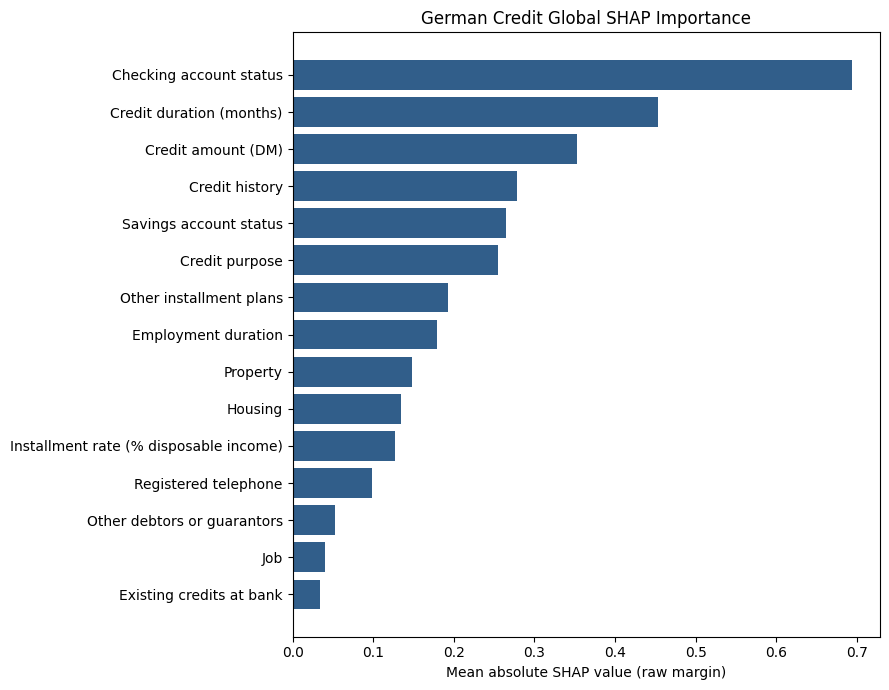

In [7]:
transformed_importance = transformed_mapping.copy()
transformed_importance["mean_abs_shap"] = np.abs(shap_values_transformed).mean(axis=0)
transformed_importance = transformed_importance.sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
TRANSFORMED_IMPORTANCE_PATH = ARTIFACTS_DIR / "shap_transformed_importance.csv"
transformed_importance.to_csv(TRANSFORMED_IMPORTANCE_PATH, index=False)

global_importance = pd.DataFrame({
    "original_feature": selected_features,
    "display_feature": [display_mapping[feature] for feature in selected_features],
    "mean_abs_shap": np.abs(aggregated_shap).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
GLOBAL_IMPORTANCE_PATH = ARTIFACTS_DIR / "shap_global_importance.csv"
global_importance.to_csv(GLOBAL_IMPORTANCE_PATH, index=False)
display(global_importance)

plot_data = global_importance.head(15).sort_values("mean_abs_shap")
plt.figure(figsize=(9, 7))
plt.barh(plot_data["display_feature"], plot_data["mean_abs_shap"], color="#315E8A")
plt.xlabel("Mean absolute SHAP value (raw margin)")
plt.title("German Credit Global SHAP Importance")
plt.tight_layout()
GLOBAL_PLOT_PATH = PLOTS_DIR / "german_credit_shap_global_importance.png"
plt.savefig(GLOBAL_PLOT_PATH, dpi=180, bbox_inches="tight")
plt.show()


## 7. Local explanations and top factors


In [8]:
def display_value(feature, value):
    if feature in category_mapping:
        return category_mapping[feature].get(str(value), str(value))
    if isinstance(value, (float, np.floating)):
        return f"{value:g}"
    return str(value)

local_rows = []
for case_number, case in enumerate(xai_cases.itertuples(index=False)):
    position = case_positions[case_number]
    raw_row = X_test_raw.iloc[position]
    contributions = aggregated_shap[position]
    ranking = np.argsort(-np.abs(contributions))
    ranks = np.empty(len(selected_features), dtype=int)
    ranks[ranking] = np.arange(1, len(selected_features) + 1)
    for feature_position, feature in enumerate(selected_features):
        shap_value = float(contributions[feature_position])
        local_rows.append({
            "case_id": case.case_id,
            "row_index": int(case.row_index),
            "true_target": int(case.true_target),
            "predicted_class": int(case.predicted_class),
            "predicted_probability": float(case.predicted_probability),
            "original_feature": feature,
            "display_feature": display_mapping[feature],
            "display_value": display_value(feature, raw_row[feature]),
            "shap_value": shap_value,
            "direction": "increases higher-risk model output" if shap_value > 0 else ("decreases higher-risk model output" if shap_value < 0 else "no contribution"),
            "rank": int(ranks[feature_position]),
        })
local_explanations = pd.DataFrame(local_rows).sort_values(["case_id", "rank"])
LOCAL_PATH = ARTIFACTS_DIR / "shap_local_explanations.csv"
local_explanations.to_csv(LOCAL_PATH, index=False)

top_factors = local_explanations.loc[local_explanations["rank"].le(5)].copy()
TOP_FACTORS_PATH = ARTIFACTS_DIR / "shap_top_factors.csv"
top_factors.to_csv(TOP_FACTORS_PATH, index=False)
assert len(local_explanations) == 20 * 17
assert len(top_factors) == 20 * 5
display(top_factors.head(10))


,case_id,row_index,true_target,predicted_class,predicted_probability,original_feature,display_feature,display_value,shap_value,direction,rank
0,GER_XAI_001,11,1,1,0.946682,Attribute1,Checking account status,< 0 DM,0.705204,increases higher-risk model output,1
1,GER_XAI_001,11,1,1,0.946682,Attribute2,Credit duration (months),48,0.597124,increases higher-risk model output,2
12,GER_XAI_001,11,1,1,0.946682,Attribute15,Housing,Rent,0.338068,increases higher-risk model output,3
6,GER_XAI_001,11,1,1,0.946682,Attribute7,Employment duration,< 1 year,0.324269,increases higher-risk model output,4
4,GER_XAI_001,11,1,1,0.946682,Attribute5,Credit amount (DM),4308,0.323529,increases higher-risk model output,5
17,GER_XAI_002,832,1,1,0.925695,Attribute1,Checking account status,< 0 DM,0.711321,increases higher-risk model output,1
21,GER_XAI_002,832,1,1,0.925695,Attribute5,Credit amount (DM),11816,0.436530,increases higher-risk model output,2
18,GER_XAI_002,832,1,1,0.925695,Attribute2,Credit duration (months),45,0.410932,increases higher-risk model output,3
29,GER_XAI_002,832,1,1,0.925695,Attribute15,Housing,Rent,0.405689,increases higher-risk model output,4
22,GER_XAI_002,832,1,1,0.925695,Attribute6,Savings account status,< 100 DM,0.290028,increases higher-risk model output,5


## 8. Rule-based summaries


In [9]:
plain_rows = []
for case in xai_cases.itertuples(index=False):
    factors = top_factors.loc[top_factors["case_id"].eq(case.case_id)].sort_values("rank").head(2)
    statements = []
    for factor in factors.itertuples(index=False):
        verb = "increased" if factor.shap_value > 0 else "reduced"
        statements.append(f"{factor.display_feature} ({factor.display_value}) {verb} the model's higher-risk output")
    explanation = "; while ".join(statements) + ". These are model associations, not causal effects."
    plain_rows.append({
        "case_id": case.case_id,
        "predicted_class": int(case.predicted_class),
        "predicted_probability": float(case.predicted_probability),
        "explanation": explanation,
    })
plain_english = pd.DataFrame(plain_rows)
PLAIN_PATH = ARTIFACTS_DIR / "shap_plain_english.csv"
plain_english.to_csv(PLAIN_PATH, index=False)
display(plain_english.head())


,case_id,predicted_class,predicted_probability,explanation
0,GER_XAI_001,1,0.946682,Checking account status (< 0 DM) increased the...
1,GER_XAI_002,1,0.925695,Checking account status (< 0 DM) increased the...
2,GER_XAI_003,1,0.906782,Checking account status (< 0 DM) increased the...
3,GER_XAI_004,1,0.906360,Checking account status (< 0 DM) increased the...
4,GER_XAI_005,1,0.905507,Credit duration (months) (36) increased the mo...


## 9. Representative local waterfall

The first high-confidence positive case is used deterministically.


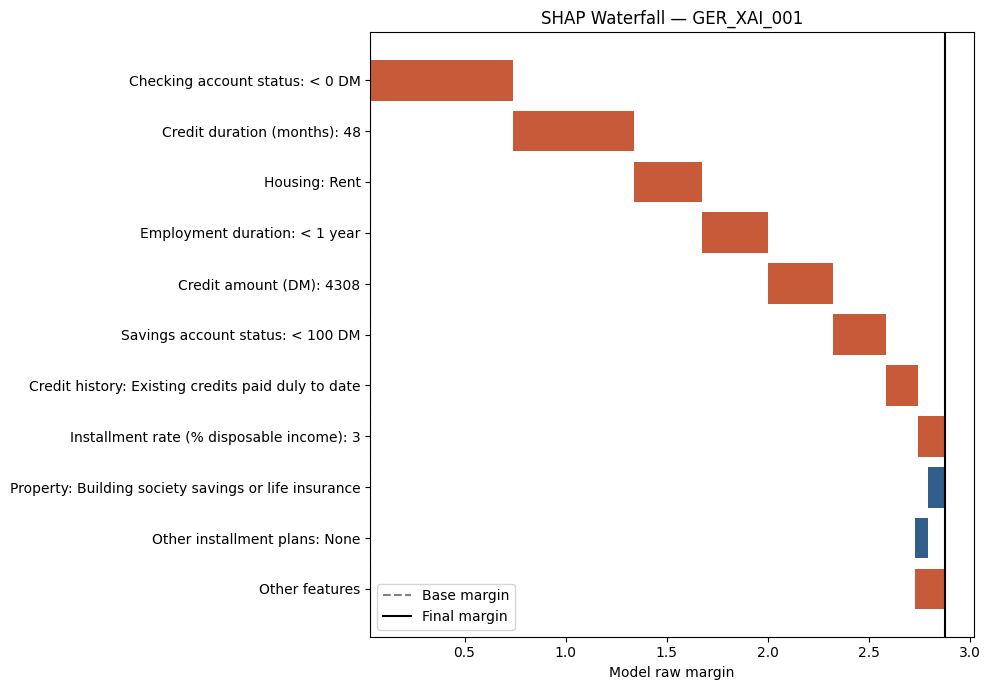

Representative case: GER_XAI_001


In [10]:
representative = xai_cases.loc[xai_cases["case_type"].eq("high-confidence positive")].iloc[0]
representative_position = test_position[int(representative["row_index"])]
representative_contributions = pd.Series(
    aggregated_shap[representative_position], index=selected_features
).sort_values(key=np.abs, ascending=False)
top_contributions = representative_contributions.head(10)
other_contribution = representative_contributions.iloc[10:].sum()
waterfall_items = list(top_contributions.items()) + [("other_features", other_contribution)]

current = float(base_values[representative_position])
starts, widths, colors, labels = [], [], [], []
for feature, contribution in waterfall_items:
    next_value = current + contribution
    starts.append(min(current, next_value))
    widths.append(abs(contribution))
    colors.append("#C75B39" if contribution > 0 else "#315E8A")
    if feature == "other_features":
        labels.append("Other features")
    else:
        raw_value = X_test_raw.loc[int(representative["row_index"]), feature]
        labels.append(f"{display_mapping[feature]}: {display_value(feature, raw_value)}")
    current = next_value

fig, ax = plt.subplots(figsize=(10, 7))
y_positions = np.arange(len(labels))
ax.barh(y_positions, widths, left=starts, color=colors)
ax.set_yticks(y_positions, labels)
ax.invert_yaxis()
ax.axvline(base_values[representative_position], color="grey", linestyle="--", label="Base margin")
ax.axvline(raw_margins[representative_position], color="black", linestyle="-", label="Final margin")
ax.set_xlabel("Model raw margin")
ax.set_title(f"SHAP Waterfall — {representative['case_id']}")
ax.legend()
plt.tight_layout()
WATERFALL_PATH = PLOTS_DIR / "german_credit_shap_representative_waterfall.png"
plt.savefig(WATERFALL_PATH, dpi=180, bbox_inches="tight")
plt.show()
print(f"Representative case: {representative['case_id']}")


## 10. Sparsity and concentration


In [11]:
sparsity_rows = []
for case_number, case in enumerate(xai_cases.itertuples(index=False)):
    absolute_values = np.sort(np.abs(aggregated_shap[case_positions[case_number]]))[::-1]
    total = absolute_values.sum()
    cumulative = np.cumsum(absolute_values) / total if total > 0 else np.zeros_like(absolute_values)
    sparsity_rows.append({
        "case_id": case.case_id,
        "non_zero_feature_count": int(np.count_nonzero(absolute_values > 1e-12)),
        "features_for_50_percent": int(np.searchsorted(cumulative, 0.50) + 1) if total > 0 else 0,
        "features_for_80_percent": int(np.searchsorted(cumulative, 0.80) + 1) if total > 0 else 0,
    })
sparsity_metrics = pd.DataFrame(sparsity_rows)
SPARSITY_PATH = ARTIFACTS_DIR / "shap_sparsity_metrics.csv"
sparsity_metrics.to_csv(SPARSITY_PATH, index=False)
display(sparsity_metrics.describe().loc[["mean", "50%", "min", "max"]])


,non_zero_feature_count,features_for_50_percent,features_for_80_percent
mean,17.0,3.25,6.9
50%,17.0,3.00,7.0
min,17.0,2.00,4.0
max,17.0,4.00,9.0


## 11. Preliminary stability diagnostic

Credit duration is perturbed by one month, bounded by the observed training range. This is a small deterministic diagnostic, not an exhaustive stability test.


In [12]:
def explain_raw_rows(frame):
    processed = preprocessor.transform(frame[selected_features])
    contributions = booster.predict(xgb.DMatrix(processed), pred_contribs=True)[:, :-1]
    aggregated = np.column_stack([
        contributions[:, feature_column_positions[feature]].sum(axis=1)
        for feature in selected_features
    ])
    probabilities = model.predict_proba(processed)[:, 1]
    return aggregated, probabilities

stability_feature = "Attribute2"
training_min = float(X_train_raw[stability_feature].min())
training_max = float(X_train_raw[stability_feature].max())
training_iqr = float(X_train_raw[stability_feature].quantile(0.75) - X_train_raw[stability_feature].quantile(0.25))
perturbation = max(1.0, round(training_iqr * 0.01))
stability_rows = []
for case_number, case in enumerate(xai_cases.head(5).itertuples(index=False)):
    original_row = X_test_raw.loc[[case.row_index], selected_features].copy()
    original_value = float(original_row.iloc[0][stability_feature])
    perturbed_value = min(original_value + perturbation, training_max)
    if np.isclose(perturbed_value, original_value):
        perturbed_value = max(original_value - perturbation, training_min)
    perturbed_row = original_row.copy()
    perturbed_row.loc[case.row_index, stability_feature] = perturbed_value
    perturbed_shap, _ = explain_raw_rows(perturbed_row)
    original_top = set(np.array(selected_features)[np.argsort(-np.abs(aggregated_shap[case_positions[case_number]]))[:5]])
    perturbed_top = set(np.array(selected_features)[np.argsort(-np.abs(perturbed_shap[0]))[:5]])
    overlap = len(original_top & perturbed_top)
    stability_rows.append({
        "case_id": case.case_id,
        "perturbed_feature": stability_feature,
        "original_value": original_value,
        "perturbed_value": perturbed_value,
        "top_5_overlap_count": overlap,
        "top_5_jaccard": overlap / len(original_top | perturbed_top),
    })
stability = pd.DataFrame(stability_rows)
STABILITY_PATH = ARTIFACTS_DIR / "shap_preliminary_stability.csv"
stability.to_csv(STABILITY_PATH, index=False)
display(stability)


,case_id,perturbed_feature,original_value,perturbed_value,top_5_overlap_count,top_5_jaccard
0,GER_XAI_001,Attribute2,48.0,49.0,5,1.0
1,GER_XAI_002,Attribute2,45.0,46.0,5,1.0
2,GER_XAI_003,Attribute2,45.0,46.0,5,1.0
3,GER_XAI_004,Attribute2,18.0,19.0,5,1.0
4,GER_XAI_005,Attribute2,36.0,37.0,5,1.0


## 12. Preliminary faithfulness diagnostic

The highest-ranked feature with a valid training-derived replacement is changed. The resulting score change measures model sensitivity, not causality.


In [13]:
training_medians = X_train_raw[numeric_features].median()
training_category_counts = {
    feature: X_train_raw[feature].value_counts()
    for feature in categorical_features
}
faithfulness_rows = []
for case_number, case in enumerate(xai_cases.head(5).itertuples(index=False)):
    original_row = X_test_raw.loc[[case.row_index], selected_features].copy()
    ranked_positions = np.argsort(-np.abs(aggregated_shap[case_positions[case_number]]))
    top_shap_feature = selected_features[ranked_positions[0]]
    intervened_feature = None
    replacement = None
    for feature_position in ranked_positions:
        feature = selected_features[feature_position]
        original_value = original_row.iloc[0][feature]
        if feature in numeric_features:
            candidate_value = float(training_medians[feature])
            if not np.isclose(float(original_value), candidate_value):
                intervened_feature, replacement = feature, candidate_value
                break
        else:
            for candidate_value in training_category_counts[feature].index:
                if candidate_value != original_value:
                    intervened_feature, replacement = feature, candidate_value
                    break
            if intervened_feature is not None:
                break
    assert intervened_feature is not None
    intervened_row = original_row.copy()
    original_value = original_row.iloc[0][intervened_feature]
    intervened_row.loc[case.row_index, intervened_feature] = replacement
    _, intervened_probabilities = explain_raw_rows(intervened_row)
    intervened_probability = float(intervened_probabilities[0])
    changed = bool(original_value != replacement)
    assert changed
    faithfulness_rows.append({
        "case_id": case.case_id,
        "top_shap_feature": top_shap_feature,
        "intervened_feature": intervened_feature,
        "original_feature_value": display_value(intervened_feature, original_value),
        "replacement_value": display_value(intervened_feature, replacement),
        "feature_actually_changed": changed,
        "original_probability": float(case.predicted_probability),
        "intervened_probability": intervened_probability,
        "absolute_score_change": abs(intervened_probability - float(case.predicted_probability)),
        "faithfulness_test_status": "completed",
    })
faithfulness = pd.DataFrame(faithfulness_rows)
FAITHFULNESS_PATH = ARTIFACTS_DIR / "shap_preliminary_faithfulness.csv"
faithfulness.to_csv(FAITHFULNESS_PATH, index=False)
display(faithfulness)


,case_id,top_shap_feature,intervened_feature,original_feature_value,replacement_value,feature_actually_changed,original_probability,intervened_probability,absolute_score_change,faithfulness_test_status
0,GER_XAI_001,Attribute1,Attribute1,< 0 DM,No checking account,True,0.946682,0.812929,0.133753,completed
1,GER_XAI_002,Attribute1,Attribute1,< 0 DM,No checking account,True,0.925695,0.649313,0.276381,completed
2,GER_XAI_003,Attribute1,Attribute1,< 0 DM,No checking account,True,0.906782,0.278392,0.628390,completed
3,GER_XAI_004,Attribute1,Attribute1,< 0 DM,No checking account,True,0.906360,0.423360,0.482999,completed
4,GER_XAI_005,Attribute2,Attribute2,36,18,True,0.905507,0.851712,0.053795,completed


## 13. Metadata and quality checks


In [14]:
SHAP_METADATA_PATH = ARTIFACTS_DIR / "shap_metadata.json"
shap_metadata = {
    "dataset": "UCI Statlog German Credit Data (ID 144)",
    "model_file": str(paths["model"].relative_to(BACKEND_DIR)),
    "preprocessor_file": str(paths["preprocessor"].relative_to(BACKEND_DIR)),
    "test_rows": len(X_test_raw),
    "explained_rows": len(shap_values_transformed),
    "transformed_feature_count": shap_values_transformed.shape[1],
    "original_selected_feature_count": len(selected_features),
    "fixed_xai_case_count": len(xai_cases),
    "shap_implementation": "XGBoost native Booster.predict(pred_contribs=True)",
    "model_output_space": "raw margin / log-odds",
    "base_value": float(base_values[0]),
    "max_raw_margin_additivity_error": max_raw_margin_error,
    "max_probability_reconstruction_error": max_probability_error,
    "global_top_feature": global_importance.iloc[0]["original_feature"],
    "representative_case": representative["case_id"],
    "stability_cases_tested": len(stability),
    "faithfulness_cases_tested": len(faithfulness),
    "model_retrained": False,
    "preprocessor_refitted": False,
}
SHAP_METADATA_PATH.write_text(json.dumps(shap_metadata, indent=2), encoding="utf-8")

assert hasattr(model, "classes_")
assert len(X_test_raw) == 200
assert max(metric_differences.values()) <= 1e-12
assert shap_values_transformed.shape == (200, 54)
assert len(xai_cases) == 20
assert len(selected_features) == 17
assert len(top_factors) == 100
assert len(sparsity_metrics) == 20
assert len(stability) == 5
assert len(faithfulness) == 5
assert faithfulness["feature_actually_changed"].all()

print("Frozen model loaded: True")
print("Exact test rows reconstructed: 200")
print("Frozen predictions reproduced: True")
print("SHAP explained rows: 200")
print("Fixed XAI cases: 20")
print("Transformed feature count: 54")
print("Original modelling features: 17")
print("Top-factor rows: 100")
print("Sparsity rows: 20")
print("Stability rows: 5")
print("Faithfulness rows: 5")
print("Model retrained: False")
print("Preprocessor refitted: False")
print("New split created: False")
print("LIME executed: False")
print("DiCE executed: False")
print("Dataset 1 modified: False")


Frozen model loaded: True
Exact test rows reconstructed: 200
Frozen predictions reproduced: True
SHAP explained rows: 200
Fixed XAI cases: 20
Transformed feature count: 54
Original modelling features: 17
Top-factor rows: 100
Sparsity rows: 20
Stability rows: 5
Faithfulness rows: 5
Model retrained: False
Preprocessor refitted: False
New split created: False
LIME executed: False
DiCE executed: False
Dataset 1 modified: False
